In [1]:
import pandas as pd
import numpy as np
import os
import torch
from tqdm import tqdm
import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['science','no-latex'])

In [2]:
import os
os.chdir('..')
os.getcwd()

'/home/ubuntu/work/saved_data/tree_height_uncertainty_quantification'

In [16]:
dem_values = pd.read_pickle('results_dataframes/dem_values.pkl')

## Load either results from our model, or results from our model without shift loss
with_shift_loss = False
if with_shift_loss:
    df_ours = pd.read_pickle('results_dataframes/results_ours.pkl')
else:
    df_ours = pd.read_pickle('results_dataframes/results_ours_wo_shift.pkl')

In [17]:
(df_ours['gedi_data'].values == dem_values['gedi_data'].values).all()
df_ours[['height_diff', 'height_measure_existent','slope_degrees']] = dem_values[['height_diff', 'height_measure_existent','slope_degrees']].values
df_with_height = df_ours[df_ours['height_measure_existent'] >= 0.5]
df_with_height['slope_bins'] = pd.cut(df_with_height['slope_degrees'], bins=[0,2,4,6,8,10,90])
df_with_height['PIW0.8'] = df_with_height['quantile_0.9'] - df_with_height['quantile_0.1']

/tmp/ipykernel_16163/2584789287.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_with_height['slope_bins'] = pd.cut(df_with_height['slope_degrees'], bins=[0,2,4,6,8,10,90])
/tmp/ipykernel_16163/2584789287.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_with_height['PIW0.8'] = df_with_height['quantile_0.9'] - df_with_height['quantile_0.1']


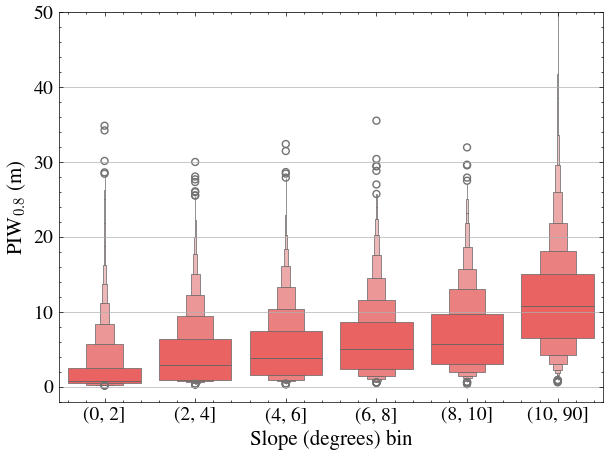

In [18]:

import seaborn as sns
plt.rcParams.update({'font.size': 14})
plt.figure(figsize=(6.4,4.8))
sns.boxenplot(data=df_with_height, x='slope_bins', y='PIW0.8', color='#FF4D4D')
plt.ylabel('PIW$_{0.8}$ (m)', fontsize=15)
plt.xlabel('Slope (degrees) bin', fontsize=15)
plt.tight_layout()
plt.grid(True, axis='y')
plt.ylim(-2,50)
if with_shift_loss:
    save_path = 'results/boxen_slope_bins.pdf'
else:
    save_path = 'results/boxen_slope_bins_wo_shift.pdf'    
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()